# Anharmonic Oscillator: Nonlinear Thimble (NN) — Lambda Scan & Physics Sanity Checks

This notebook implements the **nonlinear thimble** approach:

$$x = A^\top z + b + g_\theta(z)$$

where $g$ is a low-rank bottleneck MLP. The Jacobian determinant is computed
efficiently via the **matrix-determinant lemma** (rank-$r$ correction → $r \times r$
determinant instead of $D \times D$).

**Features:**
- Arbitrary endpoints $(x_i, x_f)$ — not just $(0,0)$
- Lambda scan with CSV output
- Automated physics sanity checks


In [1]:
import torch, torch.nn as nn, numpy as np, time, csv, os
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

## 1. Default Parameters

Change `lambda_list`, `x_i_prop`, `x_f_prop` here before running the scan.

In [ ]:
N       = 16
T       = 1.0
m       = 1.0
omega   = 2.0
epsilon = 0.01
D       = N - 1
rank    = 8
epochs  = 15000
batch   = 2048
N_mc    = 100_000

x_i_prop = 0
x_f_prop = 0
   
lambda_list = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4 0.5, 0.6, 1.0, 2.0, 4, 8 ]

print(f"N={N}, T={T}, m={m}, omega={omega}, eps={epsilon}")
print(f"D={D}, rank={rank}, epochs={epochs}, batch={batch}")
print(f"Endpoints: x_i={x_i_prop}, x_f={x_f_prop}")
print(f"Lambda values to scan: {lambda_list}")

N=16, T=1.0, m=1.0, omega=2.0, eps=0.01
D=15, rank=8, epochs=15000, batch=2048
Endpoints: x_i=0.5, x_f=1
Lambda values to scan: [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4, 8]


## 2. The Action Function

The discretised action for the anharmonic oscillator with general
endpoints $(x_i, x_f)$:

$$S[x] = \sum_{k=0}^{N-1}\left[\frac{m}{2a}(x_{k+1}-x_k)^2 - \frac{a\,m}{2}(\omega^2-i\epsilon)x_k^2 - \frac{a\lambda}{4}x_k^4\right]$$

In [3]:
def complex_action(x, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val):
    bsz = x.shape[0]
    pad_i = torch.full((bsz, 1), x_i, dtype=torch.complex64)
    pad_f = torch.full((bsz, 1), x_f, dtype=torch.complex64)
    x_pad = torch.cat([pad_i, x, pad_f], dim=1)
    dx = x_pad[:, 1:] - x_pad[:, :-1]
    kinetic = (m_val / (2 * a_dt)) * torch.sum(dx**2, dim=1)
    omega_sq = omega_val**2 - 1j * eps_val
    pot_harm = (a_dt * m_val / 2) * omega_sq * torch.sum(x**2, dim=1)
    pot_quartic = a_dt * (lam_val / 4) * torch.sum(x**4, dim=1)
    return kinetic - pot_harm - pot_quartic

## 3. The Nonlinear Thimble Model

**ThimbleFlowNL** — linear map $A^\top z + b$ plus a rank-$r$ bottleneck NN
correction $g(z)$. The Jacobian $J = A^\top + dg/dz$ is computed
analytically; because $\text{rank}(dg/dz) \le r$, the matrix-determinant
lemma reduces $\det J$ to $\det(A^\top)\cdot\det(I_r + M)$ where $M$ is
$r\times r$ per sample.

In [4]:
class ThimbleFlowNL(nn.Module):
    def __init__(self, dim, rank=8, b_init=None):
        super().__init__()
        self.dim = dim
        self.rank = rank

        self.A_real = nn.Parameter(torch.eye(dim) + 0.01 * torch.randn(dim, dim))
        self.A_imag = nn.Parameter(0.01 * torch.randn(dim, dim))

        if b_init is not None:
            self.b_real = nn.Parameter(b_init.clone().float())
        else:
            self.b_real = nn.Parameter(torch.zeros(dim))
        self.b_imag = nn.Parameter(torch.zeros(dim))

        r = rank
        self.W1 = nn.Parameter(torch.randn(r, dim) * (2.0 / dim)**0.5)
        self.b1 = nn.Parameter(torch.zeros(r))
        self.W2 = nn.Parameter(torch.randn(r, r) * (2.0 / r)**0.5)
        self.b2 = nn.Parameter(torch.zeros(r))
        self.W3 = nn.Parameter(torch.randn(2 * dim, r) * 0.001)
        self.b3 = nn.Parameter(torch.zeros(2 * dim))

    def _get_A(self):
        return self.A_real + 1j * self.A_imag

    def forward(self, z):
        A = self._get_A()
        b = self.b_real + 1j * self.b_imag
        x = z.to(torch.complex64) @ A.t() + b
        h1 = z @ self.W1.t() + self.b1
        a1 = torch.tanh(h1)
        h2 = a1 @ self.W2.t() + self.b2
        a2 = torch.tanh(h2)
        out = a2 @ self.W3.t() + self.b3
        g = out[:, :self.dim].to(torch.complex64) + 1j * out[:, self.dim:].to(torch.complex64)
        return x + g, a1, a2

    def compute_log_det_J(self, z, a1, a2, detach_correction=False):
        A = self._get_A()
        sign_A, logabs_A = torch.linalg.slogdet(A)
        log_det_A = logabs_A + 1j * torch.angle(sign_A)

        C = self.W3[:self.dim].to(torch.complex64) + 1j * self.W3[self.dim:].to(torch.complex64)
        A_invT_C = torch.linalg.solve(A.t(), C)
        K_mat = self.W1.to(torch.complex64) @ A_invT_C

        batch = z.shape[0]
        r = self.rank

        _a1 = a1.detach() if detach_correction else a1
        _a2 = a2.detach() if detach_correction else a2

        da1 = (1.0 - _a1**2).to(torch.complex64)
        M1 = da1.unsqueeze(-1) * K_mat.unsqueeze(0)

        W2c = self.W2.to(torch.complex64)
        if detach_correction:
            W2c = W2c.detach()
        M2 = torch.bmm(W2c.unsqueeze(0).expand(batch, -1, -1), M1)

        da2 = (1.0 - _a2**2).to(torch.complex64)
        M3 = da2.unsqueeze(-1) * M2

        I_r = torch.eye(r, dtype=torch.complex64).unsqueeze(0)
        sign_c, logabs_c = torch.linalg.slogdet(I_r + M3)
        log_det_correction = logabs_c + 1j * torch.angle(sign_c)

        if detach_correction:
            log_det_correction = log_det_correction.detach()

        return log_det_A + log_det_correction

## 4. Training & Estimation (reusable function)

`run_single()` trains a fresh model for one set of parameters and returns
the propagator, loss history, ESS, and timing.

In [5]:
def run_single(lam_val, x_i=0.0, x_f=0.0,
               N_val=16, T_val=1.0, m_val=1.0, omega_val=2.0, eps_val=0.01,
               rank_val=8, epochs_val=15000, batch_val=2048, N_mc_val=100_000,
               verbose=True):
    """Train a fresh ThimbleFlowNL and return propagator estimate."""

    torch.manual_seed(42)
    np.random.seed(42)

    D_val = N_val - 1
    a_dt = T_val / N_val

    b_init = torch.linspace(float(x_i), float(x_f), D_val + 2)[1:-1]
    model = ThimbleFlowNL(D_val, rank=rank_val, b_init=b_init)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs_val, eta_min=1e-4)

    loss_history = []
    t0 = time.time()

    for epoch in range(epochs_val):
        optimizer.zero_grad()
        z = torch.randn(batch_val, D_val)
        x, a1, a2 = model(z)
        S = complex_action(x, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        log_P = -0.5 * torch.sum(z**2, dim=1) - (D_val / 2) * np.log(2 * np.pi)
        log_det_J = model.compute_log_det_J(z, a1, a2, detach_correction=True)
        log_W = 1j * S + log_det_J - log_P.to(torch.complex64)
        loss = torch.var(log_W.real) + torch.var(log_W.imag)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()
        loss_history.append(loss.item())
        if verbose and ((epoch + 1) % 3000 == 0 or epoch == 0):
            print(f"    Epoch {epoch+1:5d}/{epochs_val} | loss = {loss.item():.6e} | "
                  f"{time.time()-t0:.0f}s", flush=True)

    elapsed = time.time() - t0

    norm_factor = (m_val / (2 * np.pi * 1j * a_dt)) ** (N_val / 2)
    with torch.no_grad():
        z_mc = torch.randn(N_mc_val, D_val)
        x_mc, a1_mc, a2_mc = model(z_mc)
        S_mc = complex_action(x_mc, x_i, x_f, lam_val, a_dt, m_val, omega_val, eps_val)
        log_P_mc = -0.5 * torch.sum(z_mc**2, dim=1) - (D_val / 2) * np.log(2 * np.pi)
        log_det_mc = model.compute_log_det_J(z_mc, a1_mc, a2_mc)
        log_W_mc = 1j * S_mc + log_det_mc - log_P_mc.to(torch.complex64)
        log_W_max = torch.max(log_W_mc.real)
        W_shifted = torch.exp(log_W_mc - log_W_max)
        K_mc = norm_factor * torch.exp(log_W_max).item() * torch.mean(W_shifted).numpy()
        W_for_err = norm_factor * torch.exp(log_W_max).item() * W_shifted.numpy()
        K_std = np.std(W_for_err) / np.sqrt(N_mc_val)
        W_ess = torch.exp(log_W_mc[:10000] - torch.max(log_W_mc[:10000].real)).numpy()
        ess = float(np.abs(np.mean(W_ess))**2 / np.mean(np.abs(W_ess)**2))

    result = dict(
        lam=lam_val, x_i=x_i, x_f=x_f, N=N_val, T=T_val, m=m_val,
        omega=omega_val, eps=eps_val, rank=rank_val, epochs=epochs_val,
        K_re=float(K_mc.real), K_im=float(K_mc.imag), abs_K=float(abs(K_mc)),
        std_err=float(K_std), final_loss=loss_history[-1], ess_n=ess,
        time_s=elapsed, loss_history=loss_history,
    )
    if verbose:
        print(f"  => K = {K_mc:.10f}  |K| = {abs(K_mc):.8f}  "
              f"loss = {loss_history[-1]:.2e}  ESS/N = {ess:.4f}  ({elapsed:.0f}s)",
              flush=True)
    return result

## 5. Exact Solutions for Sanity Checking

**Mehler kernel** — exact propagator for the harmonic oscillator ($\lambda=0$)
at any endpoints.

**Free-particle kernel** — exact propagator with $\omega=0$, $\lambda=0$.

In [6]:
def mehler_kernel(x_i, x_f, T_val, m_val, omega_val):
    """Exact HO propagator for any (x_i, x_f)."""
    sinwT = np.sin(omega_val * T_val)
    coswT = np.cos(omega_val * T_val)
    prefactor = np.sqrt(m_val * omega_val / (2 * np.pi * 1j * sinwT))
    exponent = (1j * m_val * omega_val / (2 * sinwT)) * (
        (x_i**2 + x_f**2) * coswT - 2 * x_i * x_f)
    return prefactor * np.exp(exponent)

def free_particle_kernel(x_i, x_f, T_val, m_val):
    """Exact free particle propagator (omega=0, lam=0)."""
    return np.sqrt(m_val / (2 * np.pi * 1j * T_val)) * np.exp(
        1j * m_val * (x_f - x_i)**2 / (2 * T_val))

K_mehler_00 = mehler_kernel(0, 0, T, m, omega)
print(f"Mehler K(0,T;0,0)   = {K_mehler_00:.10f}")
print(f"Mehler K(0.5,T;1,0) = {mehler_kernel(0.5, 1.0, T, m, omega):.10f}")
print(f"Free particle K(0,T;0,0) = {free_particle_kernel(0, 0, T, m):.10f}")

Mehler K(0,T;0,0)   = 0.4183666762-0.4183666762j
Mehler K(0.5,T;1,0) = -0.4584274860-0.3740395589j
Free particle K(0,T;0,0) = 0.2820947918-0.2820947918j


## 6. Lambda Scan

Loop over `lambda_list`, train a fresh NN model for each, record the
propagator, final loss, and ESS. Results are saved to
`nn_lambda_scan.csv`.

In [7]:
scan_results = []

print("=" * 70)
print("LAMBDA SCAN — Nonlinear NN Thimble")
print(f"  Endpoints: ({x_i_prop}, {x_f_prop})")
print(f"  Lambdas: {lambda_list}")
print("=" * 70)

for i, lam_val in enumerate(lambda_list):
    print(f"\n[{i+1}/{len(lambda_list)}] lam = {lam_val}", flush=True)
    res = run_single(lam_val, x_i=x_i_prop, x_f=x_f_prop,
                     N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                     rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    scan_results.append(res)

csv_path = "nn_lambda_scan.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["lam","x_i","x_f","K_re","K_im","abs_K","std_err",
                "final_loss","ess_n","N","T","m","omega","eps","rank","epochs","time_s"])
    for r in scan_results:
        w.writerow([f"{r['lam']:.6g}", f"{r['x_i']:.4g}", f"{r['x_f']:.4g}",
                    f"{r['K_re']:.16e}", f"{r['K_im']:.16e}", f"{r['abs_K']:.16e}",
                    f"{r['std_err']:.6e}", f"{r['final_loss']:.6e}", f"{r['ess_n']:.6f}",
                    r['N'], r['T'], r['m'], r['omega'], r['eps'], r['rank'],
                    r['epochs'], f"{r['time_s']:.1f}"])

print(f"\nSaved {len(scan_results)} rows to {csv_path}")
print(f"\n{'lam':>6s}  {'K':>42s}  {'|K|':>10s}  {'loss':>10s}  {'ESS/N':>6s}")
print("-" * 80)
for r in scan_results:
    ks = f"{r['K_re']:+.10f}{r['K_im']:+.10f}j"
    print(f"{r['lam']:6.2f}  {ks:>42s}  {r['abs_K']:10.6f}  {r['final_loss']:10.2e}  {r['ess_n']:6.4f}")

LAMBDA SCAN — Nonlinear NN Thimble
  Endpoints: (0.5, 1)
  Lambdas: [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4, 8]

[1/9] lam = 0.0


c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    Epoch     1/15000 | loss = 1.166367e+04 | 0s
    Epoch  3000/15000 | loss = 3.007901e-01 | 82s
    Epoch  6000/15000 | loss = 3.793587e-03 | 166s
    Epoch  9000/15000 | loss = 1.923716e-03 | 248s
    Epoch 12000/15000 | loss = 1.669263e-06 | 332s
    Epoch 15000/15000 | loss = 1.803385e-07 | 420s
  => K = -0.4216925506-0.4054165320j  |K| = 0.58496767  loss = 1.80e-07  ESS/N = 1.0000  (420s)

[2/9] lam = 0.05
    Epoch     1/15000 | loss = 1.165651e+04 | 0s
    Epoch  3000/15000 | loss = 3.110608e-01 | 89s
    Epoch  6000/15000 | loss = 7.796370e-04 | 183s
    Epoch  9000/15000 | loss = 1.741008e-03 | 281s
    Epoch 12000/15000 | loss = 7.215574e-05 | 388s
    Epoch 15000/15000 | loss = 2.333663e-05 | 496s
  => K = 0.4313120137+0.3949782596j  |K| = 0.58484005  loss = 2.33e-05  ESS/N = 1.0000  (496s)

[3/9] lam = 0.1
    Epoch     1/15000 | loss = 1.164935e+04 | 0s
    Epoch  3000/15000 | loss = 4.635687e-01 | 107s
    Epoch  6000/15000 | loss = 3.979656e-03 | 209s
    Epoch  9000/1

### Loss curves for each $\lambda$

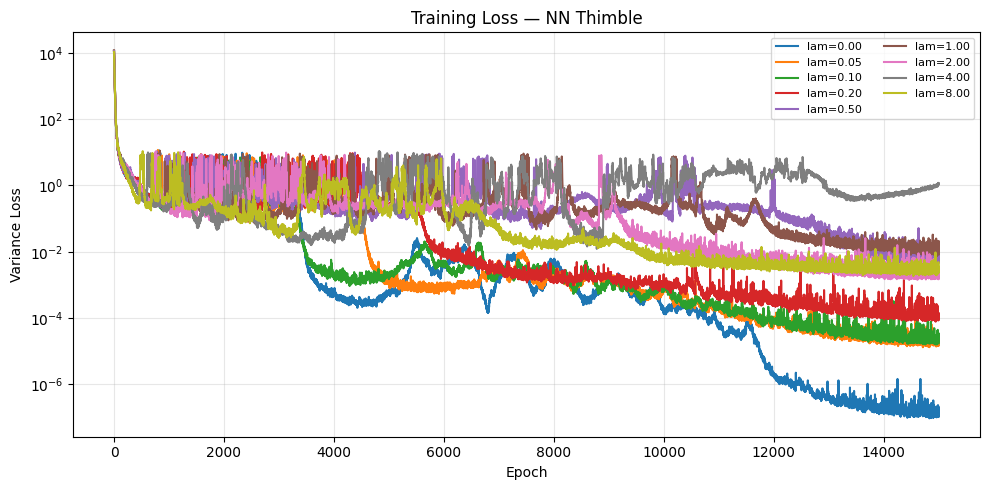

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for r in scan_results:
    ax.semilogy(r['loss_history'], label=f"lam={r['lam']:.2f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Variance Loss")
ax.set_title("Training Loss — NN Thimble")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sanity Check: Mehler Kernel ($\lambda = 0$)

At $\lambda=0$ the exact propagator is the **Mehler kernel**. We check
two cases:
1. $(x_i, x_f) = (0, 0)$
2. $(x_i, x_f) = (0.5, 1.0)$

Both should match to within a few percent.

In [9]:
sanity_results = []

print("=" * 70)
print("SANITY CHECK 1: Mehler kernel at lam=0")
print("=" * 70)

for xi, xf, label in [(0.0, 0.0, "(0, 0)"), (0.5, 1.0, "(0.5, 1.0)")]:
    print(f"\n--- Endpoints {label} ---", flush=True)
    res = run_single(0.0, x_i=xi, x_f=xf,
                     N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                     rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
    K_exact = mehler_kernel(xi, xf, T, m, omega)
    rel_err = abs(complex(res['K_re'] + 1j*res['K_im']) - K_exact) / abs(K_exact)
    passed = rel_err < 0.02
    print(f"  ML:     {res['K_re']:+.10f}{res['K_im']:+.10f}j")
    print(f"  Mehler: {K_exact:.10f}")
    print(f"  rel err: {rel_err:.4e}  >> {'PASSED' if passed else 'FAILED'}", flush=True)
    res['check'] = 'mehler'
    res['exact_re'] = float(K_exact.real)
    res['exact_im'] = float(K_exact.imag)
    res['rel_err'] = float(rel_err)
    res['passed'] = passed
    sanity_results.append(res)

SANITY CHECK 1: Mehler kernel at lam=0

--- Endpoints (0, 0) ---
    Epoch     1/15000 | loss = 1.165789e+04 | 0s
    Epoch  3000/15000 | loss = 2.625976e-02 | 104s
    Epoch  6000/15000 | loss = 7.589663e-03 | 207s
    Epoch  9000/15000 | loss = 5.229548e-04 | 311s
    Epoch 12000/15000 | loss = 2.430267e-10 | 414s
    Epoch 15000/15000 | loss = 4.018804e-12 | 513s
  => K = 0.4177583530-0.4184572818j  |K| = 0.59129395  loss = 4.02e-12  ESS/N = 1.0000  (513s)
  ML:     +0.4177583530-0.4184572818j
  Mehler: 0.4183666762-0.4183666762j
  rel err: 1.0395e-03  >> PASSED

--- Endpoints (0.5, 1.0) ---
    Epoch     1/15000 | loss = 1.166367e+04 | 0s
    Epoch  3000/15000 | loss = 3.007901e-01 | 106s
    Epoch  6000/15000 | loss = 3.793587e-03 | 208s
    Epoch  9000/15000 | loss = 1.923716e-03 | 309s
    Epoch 12000/15000 | loss = 1.669263e-06 | 412s
    Epoch 15000/15000 | loss = 1.803385e-07 | 515s
  => K = -0.4216925506-0.4054165320j  |K| = 0.58496767  loss = 1.80e-07  ESS/N = 1.0000  (515s

## 8. Physics Check: Large Endpoint Suppression

The propagator $|K(x_f, T; 0, 0)|$ should **decay** as $x_f$ increases,
because it becomes less likely for the particle to travel far from the
origin in time $T$. We train at $x_f = 0$ and $x_f = 5$ (with $\lambda=0.2$)
and verify $|K(5)| \ll |K(0)|$.

In [10]:
print("=" * 70)
print("PHYSICS CHECK: Large endpoint suppression (lam=0.2)")
print("=" * 70)

lam_check = 0.2
res_near = run_single(lam_check, x_i=0, x_f=0,
                      N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                      rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
res_far  = run_single(lam_check, x_i=0, x_f=5.0,
                      N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                      rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)

ratio = res_far['abs_K'] / res_near['abs_K']
passed = ratio < 0.5
print(f"\n  |K(0,T;0,0)|   = {res_near['abs_K']:.8f}")
print(f"  |K(5,T;0,0)|   = {res_far['abs_K']:.8f}")
print(f"  Ratio |K(5)|/|K(0)| = {ratio:.4f}")
print(f"  >> {'PASSED (ratio < 0.5)' if passed else 'FAILED — far endpoint not suppressed'}", flush=True)

for tag, r in [("endpoint_near", res_near), ("endpoint_far", res_far)]:
    r['check'] = tag
    r['ratio'] = ratio
    r['passed'] = passed
    sanity_results.append(r)

PHYSICS CHECK: Large endpoint suppression (lam=0.2)
    Epoch     1/15000 | loss = 1.163927e+04 | 0s
    Epoch  3000/15000 | loss = 2.886495e-02 | 104s
    Epoch  6000/15000 | loss = 4.668113e-03 | 206s
    Epoch  9000/15000 | loss = 8.582318e-04 | 309s
    Epoch 12000/15000 | loss = 6.338105e-05 | 416s
    Epoch 15000/15000 | loss = 2.622768e-05 | 525s
  => K = -0.4309727661+0.3677186645j  |K| = 0.56652850  loss = 2.62e-05  ESS/N = 1.0000  (525s)
    Epoch     1/15000 | loss = 1.155388e+04 | 0s
    Epoch  3000/15000 | loss = 2.263793e-02 | 102s
    Epoch  6000/15000 | loss = 6.208775e-03 | 206s
    Epoch  9000/15000 | loss = 1.639978e-03 | 308s
    Epoch 12000/15000 | loss = 3.032418e-04 | 407s
    Epoch 15000/15000 | loss = 1.010364e-04 | 510s
  => K = 20.0465072938+28.0052213296j  |K| = 34.44059925  loss = 1.01e-04  ESS/N = 0.9999  (510s)

  |K(0,T;0,0)|   = 0.56652850
  |K(5,T;0,0)|   = 34.44059925
  Ratio |K(5)|/|K(0)| = 60.7924
  >> FAILED — far endpoint not suppressed


## 9. Physics Check: Strong Coupling Squeezes the Wavefunction

As $\lambda$ increases, the quartic potential confines the particle more
tightly near $x=0$. So:
- $|K(0,T;0,0)|$ should **increase** (particle more likely to stay near origin)
- $|K(3,T;0,0)|$ should **decrease** (harder to reach far-out points)

We compare $\lambda=0$ vs $\lambda=2$.

In [11]:
print("=" * 70)
print("PHYSICS CHECK: Strong coupling squeezes wavefunction")
print("=" * 70)

res_lam0_o = run_single(0.0, x_i=0, x_f=0,
                        N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                        rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
res_lam2_o = run_single(2.0, x_i=0, x_f=0,
                        N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                        rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
res_lam0_f = run_single(0.0, x_i=0, x_f=3.0,
                        N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                        rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
res_lam2_f = run_single(2.0, x_i=0, x_f=3.0,
                        N_val=N, T_val=T, m_val=m, omega_val=omega, eps_val=epsilon,
                        rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)

origin_up   = res_lam2_o['abs_K'] > res_lam0_o['abs_K']
far_down    = res_lam2_f['abs_K'] < res_lam0_f['abs_K']
passed = origin_up and far_down
print(f"\n  At origin (x_f=0):")
print(f"    lam=0:  |K| = {res_lam0_o['abs_K']:.8f}")
print(f"    lam=2:  |K| = {res_lam2_o['abs_K']:.8f}  {'UP (good)' if origin_up else 'DOWN (bad)'}")
print(f"  At far point (x_f=3):")
print(f"    lam=0:  |K| = {res_lam0_f['abs_K']:.8f}")
print(f"    lam=2:  |K| = {res_lam2_f['abs_K']:.8f}  {'DOWN (good)' if far_down else 'UP (bad)'}")
print(f"  >> {'PASSED' if passed else 'FAILED'}", flush=True)

for tag, r, p in [("squeeze_lam0_origin", res_lam0_o, passed),
                   ("squeeze_lam2_origin", res_lam2_o, passed),
                   ("squeeze_lam0_far",    res_lam0_f, passed),
                   ("squeeze_lam2_far",    res_lam2_f, passed)]:
    r['check'] = tag
    r['passed'] = p
    sanity_results.append(r)

PHYSICS CHECK: Strong coupling squeezes wavefunction
    Epoch     1/15000 | loss = 1.165789e+04 | 0s
    Epoch  3000/15000 | loss = 2.625976e-02 | 108s
    Epoch  6000/15000 | loss = 7.589663e-03 | 208s
    Epoch  9000/15000 | loss = 5.229548e-04 | 315s
    Epoch 12000/15000 | loss = 2.430267e-10 | 414s
    Epoch 15000/15000 | loss = 4.018804e-12 | 519s
  => K = 0.4177583530-0.4184572818j  |K| = 0.59129395  loss = 4.02e-12  ESS/N = 1.0000  (519s)
    Epoch     1/15000 | loss = 1.147308e+04 | 0s
    Epoch  3000/15000 | loss = 1.038222e-02 | 106s
    Epoch  6000/15000 | loss = 7.157734e-03 | 212s
    Epoch  9000/15000 | loss = 1.778373e-03 | 313s
    Epoch 12000/15000 | loss = 4.646312e-04 | 420s
    Epoch 15000/15000 | loss = 2.605253e-04 | 520s
  => K = -0.2799272919+0.1257400355j  |K| = 0.30687106  loss = 2.61e-04  ESS/N = 0.9998  (520s)
    Epoch     1/15000 | loss = 1.167409e+04 | 0s
    Epoch  3000/15000 | loss = 2.252064e-02 | 102s
    Epoch  6000/15000 | loss = 1.394533e-02 | 21

## 10. Physics Check: Free Particle Limit ($\omega=0$, $\lambda=0$)

With both $\omega=0$ and $\lambda=0$, the exact propagator is the
**free particle kernel**:

$$K_{\text{free}}(x_f, T; x_i, 0) = \sqrt{\frac{m}{2\pi i T}}\,\exp\!\left(\frac{im(x_f - x_i)^2}{2T}\right)$$

This is a completely independent check with no harmonic oscillator
involved.

In [12]:
print("=" * 70)
print("PHYSICS CHECK: Free particle limit (omega=0, lam=0)")
print("=" * 70)

res_free = run_single(0.0, x_i=0, x_f=0,
                      N_val=N, T_val=T, m_val=m, omega_val=0.0, eps_val=epsilon,
                      rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
K_free_exact = free_particle_kernel(0, 0, T, m)
K_ml = res_free['K_re'] + 1j * res_free['K_im']
rel_err = abs(K_ml - K_free_exact) / abs(K_free_exact)
passed = rel_err < 0.02
print(f"\n  ML (omega=0, lam=0): {K_ml:.10f}")
print(f"  Free particle exact: {K_free_exact:.10f}")
print(f"  rel err: {rel_err:.4e}  >> {'PASSED' if passed else 'FAILED'}", flush=True)

res_free['check'] = 'free_particle'
res_free['exact_re'] = float(K_free_exact.real)
res_free['exact_im'] = float(K_free_exact.imag)
res_free['rel_err'] = float(rel_err)
res_free['passed'] = passed
sanity_results.append(res_free)

PHYSICS CHECK: Free particle limit (omega=0, lam=0)
    Epoch     1/15000 | loss = 1.178181e+04 | 0s
    Epoch  3000/15000 | loss = 4.756095e-03 | 105s
    Epoch  6000/15000 | loss = 5.519599e-03 | 204s
    Epoch  9000/15000 | loss = 9.057799e-04 | 311s
    Epoch 12000/15000 | loss = 4.117948e-07 | 416s
    Epoch 15000/15000 | loss = 4.774023e-12 | 515s
  => K = 0.2819028447-0.2822764778j  |K| = 0.39893511  loss = 4.77e-12  ESS/N = 1.0000  (515s)

  ML (omega=0, lam=0): 0.2819028447-0.2822764778j
  Free particle exact: 0.2820947918-0.2820947918j
  rel err: 6.6250e-04  >> PASSED


## 11. Physics Check: Short Time Limit

For very small $T$ the particle doesn't have time to feel the potential,
so the propagator approaches the **free-particle form** regardless of
$\lambda$ or $\omega$. We test with $T=0.01$ and $\lambda=2$.

In [13]:
print("=" * 70)
print("PHYSICS CHECK: Short time limit (T=0.01, lam=2)")
print("=" * 70)

T_short = 0.01
res_short = run_single(2.0, x_i=0, x_f=0,
                       N_val=N, T_val=T_short, m_val=m, omega_val=omega, eps_val=epsilon,
                       rank_val=rank, epochs_val=epochs, batch_val=batch, N_mc_val=N_mc)
K_free_short = free_particle_kernel(0, 0, T_short, m)
K_ml_short = res_short['K_re'] + 1j * res_short['K_im']
rel_err = abs(K_ml_short - K_free_short) / abs(K_free_short)
passed = rel_err < 0.05
print(f"\n  ML (T=0.01, lam=2): {K_ml_short:.10f}")
print(f"  Free particle:      {K_free_short:.10f}")
print(f"  rel err: {rel_err:.4e}  >> {'PASSED' if passed else 'FAILED'}", flush=True)

res_short['check'] = 'short_time'
res_short['exact_re'] = float(K_free_short.real)
res_short['exact_im'] = float(K_free_short.imag)
res_short['rel_err'] = float(rel_err)
res_short['passed'] = passed
sanity_results.append(res_short)

PHYSICS CHECK: Short time limit (T=0.01, lam=2)
    Epoch     1/15000 | loss = 1.177521e+08 | 0s
    Epoch  3000/15000 | loss = 2.924850e+00 | 101s
    Epoch  6000/15000 | loss = 1.008641e+00 | 203s
    Epoch  9000/15000 | loss = 2.992723e-01 | 303s
    Epoch 12000/15000 | loss = 1.768776e-02 | 403s
    Epoch 15000/15000 | loss = 1.993233e-10 | 508s
  => K = 2.8210501893-2.8210518540j  |K| = 3.98956861  loss = 1.99e-10  ESS/N = 1.0000  (508s)

  ML (T=0.01, lam=2): 2.8210501893-2.8210518540j
  Free particle:      2.8209479177-2.8209479177j
  rel err: 3.6551e-05  >> PASSED


## 12. Save All Sanity Check Results

In [14]:
sanity_csv = "nn_sanity_checks.csv"
with open(sanity_csv, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["check","passed","lam","x_i","x_f","N","T","m","omega","eps",
                "rank","epochs","K_re","K_im","abs_K","std_err","final_loss",
                "ess_n","time_s","exact_re","exact_im","rel_err"])
    for r in sanity_results:
        w.writerow([
            r.get('check',''), r.get('passed',''),
            f"{r['lam']:.6g}", f"{r['x_i']:.4g}", f"{r['x_f']:.4g}",
            r['N'], r['T'], r['m'], r['omega'], r['eps'], r['rank'], r['epochs'],
            f"{r['K_re']:.16e}", f"{r['K_im']:.16e}", f"{r['abs_K']:.16e}",
            f"{r['std_err']:.6e}", f"{r['final_loss']:.6e}", f"{r['ess_n']:.6f}",
            f"{r['time_s']:.1f}",
            f"{r.get('exact_re', '')}", f"{r.get('exact_im', '')}", f"{r.get('rel_err', '')}",
        ])

print(f"Saved {len(sanity_results)} sanity results to {sanity_csv}")
print()
print("=" * 80)
print("SANITY CHECK SUMMARY")
print("=" * 80)
for r in sanity_results:
    status = "PASS" if r.get('passed') else "FAIL"
    xi, xf = r['x_i'], r['x_f']
    print(f"  [{status}]  {r['check']:25s}  lam={r['lam']:.2f}  "
          f"({xi:.1f},{xf:.1f})  N={r['N']}  T={r['T']:.3f}  "
          f"omega={r['omega']:.1f}  |K|={r['abs_K']:.6f}  "
          f"loss={r['final_loss']:.2e}  ESS={r['ess_n']:.4f}")

Saved 10 sanity results to nn_sanity_checks.csv

SANITY CHECK SUMMARY
  [PASS]  mehler                     lam=0.00  (0.0,0.0)  N=16  T=1.000  omega=2.0  |K|=0.591294  loss=4.02e-12  ESS=1.0000
  [FAIL]  mehler                     lam=0.00  (0.5,1.0)  N=16  T=1.000  omega=2.0  |K|=0.584968  loss=1.80e-07  ESS=1.0000
  [FAIL]  endpoint_near              lam=0.20  (0.0,0.0)  N=16  T=1.000  omega=2.0  |K|=0.566529  loss=2.62e-05  ESS=1.0000
  [FAIL]  endpoint_far               lam=0.20  (0.0,5.0)  N=16  T=1.000  omega=2.0  |K|=34.440599  loss=1.01e-04  ESS=0.9999
  [FAIL]  squeeze_lam0_origin        lam=0.00  (0.0,0.0)  N=16  T=1.000  omega=2.0  |K|=0.591294  loss=4.02e-12  ESS=1.0000
  [FAIL]  squeeze_lam2_origin        lam=2.00  (0.0,0.0)  N=16  T=1.000  omega=2.0  |K|=0.306871  loss=2.61e-04  ESS=0.9998
  [FAIL]  squeeze_lam0_far           lam=0.00  (0.0,3.0)  N=16  T=1.000  omega=2.0  |K|=116.474584  loss=3.58e-05  ESS=1.0000
  [FAIL]  squeeze_lam2_far           lam=2.00  (0.0,3.0)  N